<a href="https://colab.research.google.com/github/ctr/medical-physics-demos-2026-03/blob/main/MedPhys_sliceSelBloch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Slice selection using exponential time stepping

In [8]:
# Set up the python package "bloch" that we need. This will take a moment.
!pip install git+https://github.com/ctr/bloch-simulator-python > /dev/null 2>&1

# Note that the original version was
# https://github.com/namalkanti/bloch-simulator-python
# but its setup script is incompatible with recent python versions

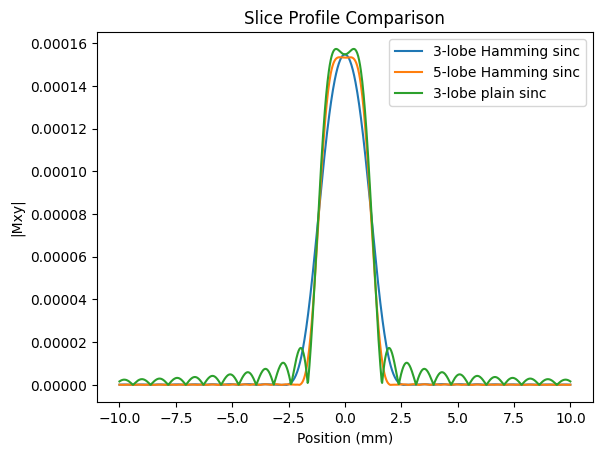

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from bloch import bloch

# -------------------------------------------------
# Simulation parameters
# -------------------------------------------------
gamma = 2 * np.pi * 42.577e6   # rad/T/s
dt = 2e-6                      # 2 us dwell time
flip_angle = np.deg2rad(90)    # 90 degree pulse
slice_thickness = 5e-3         # 5 mm
Gz = 10e-3                     # 10 mT/m slice gradient
T1 = 1.0                       # seconds
T2 = 0.1                       # seconds

# Spatial positions across slice
z = np.linspace(-10e-3, 10e-3, 1000)
df = gamma * Gz * z / (2*np.pi)   # convert these to frequency offsets (Hz) during the gradient

# -------------------------------------------------
# Function to generate non-windowed sinc pulse
# -------------------------------------------------
def sinc(num_lobes, duration, dt):
    t = np.arange(-duration/2, duration/2, dt)
    bw = num_lobes / duration
    rf = np.sinc(bw * t)
    return t, rf

# -------------------------------------------------
# Function to generate Hamming-windowed sinc pulse
# -------------------------------------------------
def hamming_sinc(num_lobes, duration, dt):
    t = np.arange(-duration/2, duration/2, dt)
    bw = num_lobes / duration
    sinc = np.sinc(bw * t)
    window = np.hamming(len(t))
    rf = sinc * window
    return t, rf

# -------------------------------------------------
# Scale RF pulse to desired flip angle
# -------------------------------------------------
def scale_rf(rf, dt, flip_angle):
    b1_area = np.sum(rf) * dt
    scale = flip_angle / (gamma * b1_area)
    return rf * scale

# --------------------------------------------------------------------------
# Create non-windowed 3-lobe, plus Hamming windowed 3-lobe and 5-lobe pulses
# --------------------------------------------------------------------------
duration_3 = 3e-3
duration_5 = 5e-3

t3, rf3 = hamming_sinc(3, duration_3, dt)
t5, rf5 = hamming_sinc(5, duration_5, dt)

t3NW, rf3NW = sinc(3, duration_3, dt)

rf3 = scale_rf(rf3, dt, flip_angle)
rf5 = scale_rf(rf5, dt, flip_angle)
rf3NW = scale_rf(rf3NW, dt, flip_angle)

# Gradient waveform (constant during RF)
gz3 = np.ones_like(rf3) * Gz
gz5 = np.ones_like(rf5) * Gz

# -------------------------------------------------
# Bloch simulation
# -------------------------------------------------
mx3, my3, mz3 = bloch(rf3, gz3, dt, T1, T2, df, 0, mode=0)
mx5, my5, mz5 = bloch(rf5, gz5, dt, T1, T2, df, 0, mode=0)

mx3NW, my3NW, mz3NW = bloch(rf3NW, gz3, dt, T1, T2, df, 0, mode=0)

mxy3 = np.abs(mx3 + 1j*my3)
mxy5 = np.abs(mx5 + 1j*my5)

mxy3NW = np.abs(mx3NW + 1j*my3NW)

# -------------------------------------------------
# Plot slice profiles
# -------------------------------------------------
plt.figure()
plt.plot(z*1e3, mxy3, label="3-lobe Hamming sinc")
plt.plot(z*1e3, mxy5, label="5-lobe Hamming sinc")
plt.plot(z*1e3, mxy3NW, label="3-lobe plain sinc")
plt.xlabel("Position (mm)")
plt.ylabel("|Mxy|")
plt.title("Slice Profile Comparison")
plt.legend()
plt.show()